In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
list_not_selected = []
a_set  = {}
for i in range(1,1001):
    possible_values = np.arange(1,10000)
    a = np.random.choice(possible_values, size=10000, replace=True)
    a_set = set(a)
    not_selc = 10000 - len(a_set)
    per_for = (not_selc / 10000) * 100
    list_not_selected.append(per_for)

In [13]:
max(list_not_selected)

37.830000000000005

In [14]:
list_not_selected

[36.39,
 36.47,
 36.46,
 36.78,
 37.05,
 36.47,
 36.64,
 36.76,
 37.01,
 36.480000000000004,
 36.49,
 37.01,
 36.66,
 36.620000000000005,
 37.15,
 36.980000000000004,
 36.58,
 36.41,
 37.03,
 37.46,
 36.11,
 36.04,
 36.39,
 37.16,
 36.99,
 37.019999999999996,
 36.85,
 37.25,
 36.720000000000006,
 36.730000000000004,
 36.58,
 37.16,
 36.980000000000004,
 37.61,
 36.74,
 36.309999999999995,
 36.84,
 37.12,
 36.120000000000005,
 36.559999999999995,
 36.53,
 36.58,
 37.29,
 36.82,
 36.64,
 36.86,
 36.85,
 36.55,
 36.88,
 36.49,
 36.55,
 36.74,
 36.96,
 36.55,
 37.019999999999996,
 36.870000000000005,
 36.82,
 37.419999999999995,
 37.2,
 36.86,
 36.480000000000004,
 36.11,
 36.15,
 36.67,
 36.68,
 36.55,
 36.730000000000004,
 36.980000000000004,
 36.82,
 36.85,
 37.11,
 36.5,
 37.019999999999996,
 36.68,
 36.59,
 36.5,
 36.89,
 36.68,
 36.93,
 36.77,
 37.019999999999996,
 36.94,
 36.18,
 37.19,
 37.04,
 36.620000000000005,
 36.8,
 36.720000000000006,
 36.82,
 37.08,
 36.95,
 36.7,
 37.19,
 

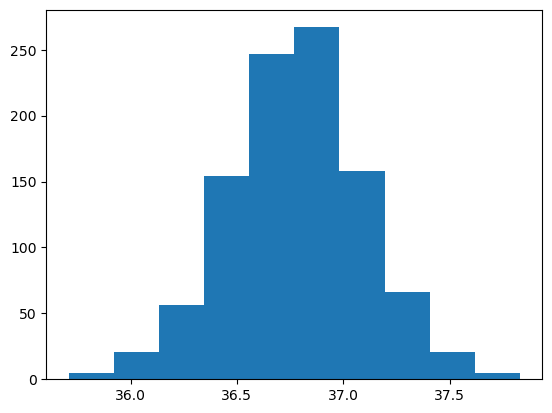

In [15]:
plt.hist(list_not_selected)
plt.show()

In [16]:
df = pd.DataFrame(list_not_selected)

In [17]:
df.describe()

,0
count,1000.000000
mean,36.776490
std,0.315209
min,35.710000
25%,36.570000
50%,36.780000
75%,36.982500
max,37.830000


In [18]:
np_array = np.array(list_not_selected)

In [19]:
np_array_means = np.mean(np_array)
np_array_means

36.77649

In [20]:
np_array_standar_dev = np.std(np_array)
np_array_standar_dev

0.31505170988267944

In [22]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris


data = load_iris()
X = data.data
y = data.target

X = X[:100, :]
y = y[:100]

# no of folds
K = 5

folds = np.random.choice(K, size=X.shape[0], replace=True)

X_test = X[folds == 0]
y_test = y[folds == 0]

X_train = X[folds != 0]
y_train = y[folds != 0]

# Bagging model

from sklearn.ensemble import BaggingClassifier

# default base estimator is Decision Tree with default hyperparameters

clf = BaggingClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)

# get performance metrics
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tp = cm[0,0]
tn = cm[1,1]
fp = cm[1,0]
fn = cm[0,1]

accuaracy = (tp + tn) / cm.sum()
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

#################################################################

# base model is Decision Tree with max_depth=3

from sklearn.tree import DecisionTreeClassifier

base_estimator = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    splitter='best')

clf = BaggingClassifier(estimator=base_estimator, 
                        n_estimators=100)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
tp = cm[0,0]
tn = cm[1,1]
fp = cm[1,0]
fn = cm[0,1]

accuaracy = (tp + tn) / cm.sum()
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"accurcary: {accuaracy}")
###########################################################################

# base model is KNN with k=3

from sklearn.neighbors import KNeighborsClassifier
base_estimator = KNeighborsClassifier(n_neighbors=3)

clf = BaggingClassifier(estimator=base_estimator, 
                        n_estimators=100)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
tp = cm[0,0]
tn = cm[1,1]
fp = cm[1,0]
fn = cm[0,1]

accuaracy = (tp + tn) / cm.sum()
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

###########################################################################

mcc_formula = (tp*tn - fp*fn) / np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))

from sklearn.metrics import matthews_corrcoef
mcc = matthews_corrcoef(y_test, y_pred)


accurcary: 1.0


In [33]:
rng = np.random.RandomState(42)
np.random.seed(42)
np.random.random(5)

array([0.37454012, 0.95071431, 0.73199394, 0.59865848, 0.15601864])

In [35]:
np.random.seed(42)
np.random.random(5)

array([0.37454012, 0.95071431, 0.73199394, 0.59865848, 0.15601864])